# Reduced sine-Gordon examples

The `RSG` constructor uses an integer continued-fraction list.
Its `pair()` method constructs $(A_+,A_-)$; `t_datum()` validates the
constructed pair, with identity symmetrizer in the examples below.

This notebook verifies six explicit inputs. These computations do not prove
a statement about all parameter lists or determine a nonlinear period.


In [1]:
from tdatum.examples import RSG

constructor = RSG([3, 1])
td = constructor.t_datum()
assert td.degrees() == (2, 6)
td.pair()

(
[ 1 + z^2       -z]  [1 + z^2       0]
[-z - z^5  1 + z^6], [   -z^3 1 + z^6]
)

The row order is the constructor's index order. Recording it makes the correspondence between matrix entries and mathematical labels explicit.

In [2]:
list(zip(constructor.indices(), td.degrees()))

[((1, 1), 2), ((2, 1), 6)]

In [3]:
cases = [[2,1], [3,1], [4,1], [3,2,2], [4,2,3], [3,2,2,2]]
records = []
for parameters in cases:
    datum = RSG(parameters).t_datum()
    ap, am = datum.pair()
    z = datum.variable()
    assert ap * am.transpose().subs({z: 1/z}) == am * ap.transpose().subs({z: 1/z})
    records.append((parameters, datum.size(), datum.degrees()))
records

[([2, 1], 1, (4,)),
 ([3, 1], 2, (2, 6)),
 ([4, 1], 3, (2, 2, 8)),
 ([3, 2, 2], 5, (2, 6, 6, 14, 14)),
 ([4, 2, 3], 7, (2, 2, 8, 8, 18, 18, 18)),
 ([3, 2, 2, 2], 7, (2, 6, 6, 14, 14, 34, 34))]

## Plot the initial quiver

`plot_mutation_loop()` draws the initial quiver of the maximal mutation-loop
construction. Its vertex labels are the zero-based pairs $(a,p)$ returned
by `maximal_initial_indices()`: $a$ is the matrix row and $0 \le p < p_a$.
Green vertices have $p=0$ and are mutated in the first time step.


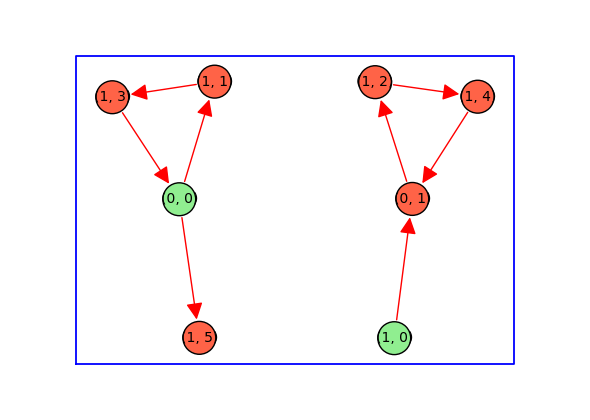

In [4]:
plot = td.plot_mutation_loop()
plot.show(figsize=6, axes_pad=0.15)

A mutation loop can also be constructed from a T-datum. The following test recovers the original matrix pair from the maximal construction.

In [5]:
loop = td.mutation_loop()
assert loop.is_complete()
recovered = loop.t_datum()
assert recovered.pair() == td.pair()
{"quiver_vertices": loop.size(), "time_steps": loop.length(), "mutations": loop.whole_length()}

{'quiver_vertices': 8, 'time_steps': 1, 'mutations': 2}